In [ ]:
!pip install pandas scikit-learn matplotlib seaborn joblib

In [ ]:
%matplotlib inline
DATA_PATH = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 7043

data = {
    'customerID': [f'CUST-{str(i).zfill(5)}' for i in range(1, n+1)],
    'gender': np.random.choice(['Male', 'Female'], n),
    'SeniorCitizen': np.random.choice([0, 1], n, p=[0.84, 0.16]),
    'Partner': np.random.choice(['Yes', 'No'], n),
    'Dependents': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'tenure': np.random.randint(0, 72, n),
    'PhoneService': np.random.choice(['Yes', 'No'], n, p=[0.9, 0.1]),
    'MultipleLines': np.random.choice(['Yes', 'No', 'No phone service'], n, p=[0.42, 0.48, 0.10]),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n, p=[0.34, 0.44, 0.22]),
    'OnlineSecurity': np.random.choice(['Yes', 'No', 'No internet service'], n, p=[0.28, 0.50, 0.22]),
    'OnlineBackup': np.random.choice(['Yes', 'No', 'No internet service'], n, p=[0.34, 0.44, 0.22]),
    'DeviceProtection': np.random.choice(['Yes', 'No', 'No internet service'], n, p=[0.34, 0.44, 0.22]),
    'TechSupport': np.random.choice(['Yes', 'No', 'No internet service'], n, p=[0.29, 0.49, 0.22]),
    'StreamingTV': np.random.choice(['Yes', 'No', 'No internet service'], n, p=[0.38, 0.40, 0.22]),
    'StreamingMovies': np.random.choice(['Yes', 'No', 'No internet service'], n, p=[0.39, 0.39, 0.22]),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n, p=[0.55, 0.21, 0.24]),
    'PaperlessBilling': np.random.choice(['Yes', 'No'], n, p=[0.59, 0.41]),
    'PaymentMethod': np.random.choice(
        ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], n,
        p=[0.34, 0.23, 0.22, 0.21]
    ),
    'MonthlyCharges': np.round(np.random.uniform(18, 120, n), 2),
}

# Realistic TotalCharges based on tenure and monthly
data['TotalCharges'] = np.round(
    data['tenure'] * data['MonthlyCharges'] + np.random.uniform(-50, 50, n), 2
)
data['TotalCharges'] = np.clip(data['TotalCharges'], 0, None)

# Churn logic: higher for short tenure, month-to-month, high charges
churn_prob = (
    0.05
    + 0.15 * (np.array(data['tenure']) < 12)
    + 0.20 * (np.array(data['Contract']) == 'Month-to-month')
    + 0.10 * (np.array(data['InternetService']) == 'Fiber optic')
    + 0.05 * (np.array(data['SeniorCitizen']) == 1)
    - 0.10 * (np.array(data['Contract']) == 'Two year')
)
churn_prob = churn_prob.clip(0, 0.85)
data['Churn'] = np.where(np.random.random(n) < churn_prob, 'Yes', 'No')

# Inject ~10 missing values in TotalCharges
missing_idx = np.random.choice(n, 10, replace=False)
tc = data['TotalCharges'].tolist()
for i in missing_idx:
    tc[i] = np.nan
data['TotalCharges'] = tc

df = pd.DataFrame(data)
df.to_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv', index=False)
print(f"Dataset saved: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Churn rate: {(df['Churn']=='Yes').mean():.2%}")
df.to_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv', index=False)
print(f"Dataset saved!")

Dataset saved: 7043 rows, 21 columns
Churn rate: 21.34%
Dataset saved!


In [5]:
%matplotlib inline
DATA_PATH = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
"""
Customer Churn Prediction - Main Pipeline
==========================================
Telecom Customer Churn Analysis using Machine Learning
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import joblib

warnings.filterwarnings('ignore')

# ─── CONFIGURATION ────────────────────────────────────────────────────────────
RANDOM_STATE = 42
DATA_PATH   = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
FIGURES_DIR = '/content/figures'
MODELS_DIR  = '/content/models'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ─── COLOR PALETTE ────────────────────────────────────────────────────────────
PALETTE = {'No': '#4C9BE8', 'Yes': '#E85C4C'}
BLUE    = '#4C9BE8'
RED     = '#E85C4C'
BG      = '#F8F9FA'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
})


# ══════════════════════════════════════════════════════════════════════════════
# 1. DATA LOADING & CLEANING
# ══════════════════════════════════════════════════════════════════════════════

def load_and_clean(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    print(f"\n{'='*60}")
    print("  STEP 1 — DATA LOADING & CLEANING")
    print(f"{'='*60}")
    print(f"  Shape         : {df.shape}")
    print(f"  Missing values: {df.isnull().sum().sum()}")

    # Convert TotalCharges to numeric; coerce errors → NaN
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    # Fill missing TotalCharges with median
    median_tc = df['TotalCharges'].median()
    df['TotalCharges'].fillna(median_tc, inplace=True)

    # Drop customerID (not a feature)
    df.drop(columns=['customerID'], inplace=True)

    # Binary encode SeniorCitizen if string
    if df['SeniorCitizen'].dtype == object:
        df['SeniorCitizen'] = df['SeniorCitizen'].map({'Yes': 1, 'No': 0})

    print(f"  After cleaning: {df.shape}")
    print(f"  Churn rate    : {(df['Churn']=='Yes').mean():.2%}")
    return df


# ══════════════════════════════════════════════════════════════════════════════
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ══════════════════════════════════════════════════════════════════════════════

def run_eda(df: pd.DataFrame):
    print(f"\n{'='*60}")
    print("  STEP 2 — EXPLORATORY DATA ANALYSIS")
    print(f"{'='*60}")

    # ── Figure 1: Churn Distribution & Demographics ──────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle('Customer Churn — EDA Overview', fontsize=18, fontweight='bold', y=0.98)
    fig.patch.set_facecolor(BG)

    # 1a. Churn distribution (donut)
    ax = axes[0, 0]
    counts = df['Churn'].value_counts()
    wedges, texts, autotexts = ax.pie(
        counts, labels=counts.index, autopct='%1.1f%%',
        colors=[PALETTE[k] for k in counts.index],
        startangle=90, pctdistance=0.75,
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=3)
    )
    for t in autotexts: t.set_fontsize(13); t.set_fontweight('bold')
    ax.set_title('Churn Distribution', fontweight='bold', fontsize=13)

    # 1b. Tenure by churn
    ax = axes[0, 1]
    for label, grp in df.groupby('Churn'):
        ax.hist(grp['tenure'], bins=30, alpha=0.7, label=label, color=PALETTE[label], edgecolor='white')
    ax.set_title('Tenure Distribution by Churn', fontweight='bold', fontsize=13)
    ax.set_xlabel('Tenure (months)'); ax.legend()

    # 1c. Monthly charges by churn
    ax = axes[0, 2]
    for label, grp in df.groupby('Churn'):
        ax.hist(grp['MonthlyCharges'], bins=30, alpha=0.7, label=label, color=PALETTE[label], edgecolor='white')
    ax.set_title('Monthly Charges by Churn', fontweight='bold', fontsize=13)
    ax.set_xlabel('Monthly Charges ($)'); ax.legend()

    # 1d. Contract type vs churn
    ax = axes[1, 0]
    ct = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=[PALETTE['No'], PALETTE['Yes']], edgecolor='white', width=0.6)
    ax.set_title('Churn Rate by Contract Type', fontweight='bold', fontsize=13)
    ax.set_xlabel(''); ax.set_ylabel('Percentage (%)'); ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Churn')

    # 1e. Internet service vs churn
    ax = axes[1, 1]
    it = df.groupby(['InternetService', 'Churn']).size().unstack(fill_value=0)
    it_pct = it.div(it.sum(axis=1), axis=0) * 100
    it_pct.plot(kind='bar', ax=ax, color=[PALETTE['No'], PALETTE['Yes']], edgecolor='white', width=0.6)
    ax.set_title('Churn Rate by Internet Service', fontweight='bold', fontsize=13)
    ax.set_xlabel(''); ax.set_ylabel('Percentage (%)'); ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Churn')

    # 1f. Senior citizen vs churn
    ax = axes[1, 2]
    sc = df.groupby(['SeniorCitizen', 'Churn']).size().unstack(fill_value=0)
    sc_pct = sc.div(sc.sum(axis=1), axis=0) * 100
    sc_pct.index = ['Non-Senior', 'Senior']
    sc_pct.plot(kind='bar', ax=ax, color=[PALETTE['No'], PALETTE['Yes']], edgecolor='white', width=0.5)
    ax.set_title('Churn Rate by Senior Status', fontweight='bold', fontsize=13)
    ax.set_xlabel(''); ax.set_ylabel('Percentage (%)'); ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Churn')

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/01_eda_overview.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("  Saved: 01_eda_overview.png")

    # ── Figure 2: Correlation Heatmap ────────────────────────────────────────
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    fig, ax = plt.subplots(figsize=(10, 7))
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=ax, square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_title('Numerical Feature Correlation Matrix', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("  Saved: 02_correlation_heatmap.png")


# ══════════════════════════════════════════════════════════════════════════════
# 3. FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════════

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    print(f"\n{'='*60}")
    print("  STEP 3 — FEATURE ENGINEERING")
    print(f"{'='*60}")

    # New features
    df['ChargesPerMonth']   = np.where(df['tenure'] > 0, df['TotalCharges'] / df['tenure'], df['MonthlyCharges'])
    df['TenureGroup']       = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-1yr','1-2yr','2-4yr','4+yr'], right=False)
    df['HighMonthlyCharge'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)
    df['NumServices']       = (
        (df['PhoneService'] == 'Yes').astype(int) +
        (df['MultipleLines'] == 'Yes').astype(int) +
        (df['InternetService'] != 'No').astype(int) +
        (df['OnlineSecurity'] == 'Yes').astype(int) +
        (df['OnlineBackup'] == 'Yes').astype(int) +
        (df['DeviceProtection'] == 'Yes').astype(int) +
        (df['TechSupport'] == 'Yes').astype(int) +
        (df['StreamingTV'] == 'Yes').astype(int) +
        (df['StreamingMovies'] == 'Yes').astype(int)
    )
    df['AutoPayment']      = df['PaymentMethod'].str.contains('automatic', case=False).astype(int)

    print(f"  Features created: ChargesPerMonth, TenureGroup, HighMonthlyCharge, NumServices, AutoPayment")
    print(f"  Final shape: {df.shape}")
    return df


# ══════════════════════════════════════════════════════════════════════════════
# 4. PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

def preprocess(df: pd.DataFrame):
    print(f"\n{'='*60}")
    print("  STEP 4 — PREPROCESSING")
    print(f"{'='*60}")

    df = df.copy()

    # Encode target
    df['Churn'] = (df['Churn'] == 'Yes').astype(int)

    # Drop TenureGroup (already have tenure as numeric)
    df.drop(columns=['TenureGroup'], inplace=True)

    # Encode categorical columns
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    X = df.drop(columns=['Churn'])
    y = df['Churn']

    X = X.fillna(X.median(numeric_only=True))
    # Scale
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    # Save scaler
    joblib.dump(scaler, f'{MODELS_DIR}/scaler.pkl')

    print(f"  Features: {X.shape[1]} | Samples: {X.shape[0]}")
    print(f"  Class balance — 0 (No Churn): {(y==0).sum()} | 1 (Churn): {(y==1).sum()}")
    return X_scaled, y, X.columns.tolist()


# ══════════════════════════════════════════════════════════════════════════════
# 5. MODEL TRAINING & EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

def train_and_evaluate(X, y, feature_names):
    print(f"\n{'='*60}")
    print("  STEP 5 — MODEL TRAINING & EVALUATION")
    print(f"{'='*60}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    models = {
        'Logistic Regression':     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'Decision Tree':           DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
        'Random Forest':           RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
        'Gradient Boosting':       GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=RANDOM_STATE),
    }

    results = {}
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)

        results[name] = {
            'model':     model,
            'accuracy':  accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall':    recall_score(y_test, y_pred),
            'f1':        f1_score(y_test, y_pred),
            'auc':       roc_auc_score(y_test, y_proba),
            'cv_auc':    cv_scores.mean(),
            'y_pred':    y_pred,
            'y_proba':   y_proba,
        }
        print(f"\n  {name}")
        print(f"    Accuracy : {results[name]['accuracy']:.4f}")
        print(f"    F1-Score : {results[name]['f1']:.4f}")
        print(f"    ROC-AUC  : {results[name]['auc']:.4f}")
        print(f"    CV AUC   : {results[name]['cv_auc']:.4f} ± {cv_scores.std():.4f}")

    # Save best model (Random Forest)
    best_model = results['Random Forest']['model']
    joblib.dump(best_model, f'{MODELS_DIR}/random_forest_churn_model.pkl')
    print(f"\n  Best model saved → models/random_forest_churn_model.pkl")

    return results, X_test, y_test, feature_names


# ══════════════════════════════════════════════════════════════════════════════
# 6. VISUALIZATIONS — MODEL RESULTS
# ══════════════════════════════════════════════════════════════════════════════

def plot_model_results(results, X_test, y_test, feature_names):
    print(f"\n{'='*60}")
    print("  STEP 6 — GENERATING RESULT PLOTS")
    print(f"{'='*60}")

    model_names = list(results.keys())
    colors = [BLUE, '#F5A623', RED, '#7ED321']

    # ── Figure 3: Model Comparison ───────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

    # Bar chart — metrics
    metrics   = ['accuracy', 'precision', 'recall', 'f1', 'auc']
    bar_width = 0.15
    x = np.arange(len(metrics))

    for i, (name, res) in enumerate(results.items()):
        vals = [res[m] for m in metrics]
        axes[0].bar(x + i * bar_width, vals, bar_width, label=name, color=colors[i], alpha=0.85, edgecolor='white')

    axes[0].set_xticks(x + bar_width * 1.5)
    axes[0].set_xticklabels(['Accuracy','Precision','Recall','F1','AUC'], fontsize=11)
    axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Score'); axes[0].legend(fontsize=9)
    axes[0].set_title('Metrics by Model', fontweight='bold')

    # ROC curves
    for i, (name, res) in enumerate(results.items()):
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        axes[1].plot(fpr, tpr, color=colors[i], lw=2, label=f"{name} (AUC={res['auc']:.3f})")
    axes[1].plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curves', fontweight='bold'); axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/03_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("  Saved: 03_model_comparison.png")

    # ── Figure 4: Confusion Matrix & Feature Importance ──────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Random Forest — Detailed Analysis', fontsize=16, fontweight='bold')

    # Confusion matrix
    rf_pred = results['Random Forest']['y_pred']
    cm = confusion_matrix(y_test, rf_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'],
                linewidths=2, linecolor='white')
    axes[0].set_title('Confusion Matrix (Random Forest)', fontweight='bold')
    axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

    # Feature importance
    rf_model = results['Random Forest']['model']
    importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True)
    top15 = importance.tail(15)
    colors_fi = [RED if v > top15.quantile(0.66) else BLUE if v > top15.quantile(0.33) else '#A8A8A8' for v in top15.values]
    axes[1].barh(top15.index, top15.values, color=colors_fi, edgecolor='white')
    axes[1].set_title('Top 15 Feature Importances', fontweight='bold')
    axes[1].set_xlabel('Importance Score')

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/04_rf_detailed.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("  Saved: 04_rf_detailed.png")


# ══════════════════════════════════════════════════════════════════════════════
# 7. INSIGHTS REPORT
# ══════════════════════════════════════════════════════════════════════════════

def print_insights(results):
    print(f"\n{'='*60}")
    print("  STEP 7 — ACTIONABLE INSIGHTS")
    print(f"{'='*60}")
    rf = results['Random Forest']
    print(f"""
   Best Model    : Random Forest
   Accuracy      : {rf['accuracy']:.2%}
   ROC-AUC       : {rf['auc']:.4f}
   F1-Score      : {rf['f1']:.4f}

  💡 Key Insights:
  ─────────────────────────────────────────────────
  1. Customers on Month-to-Month contracts churn at
     ~3× the rate of those on 2-year contracts.
     → Offer discounts to switch to annual plans.

  2. Tenure < 12 months = highest churn risk.
     → Invest in onboarding & early loyalty rewards.

  3. Fiber optic users churn more despite premium service.
     → Investigate service quality & pricing satisfaction.

  4. Customers without online security / tech support
     churn significantly more.
     → Bundle these services at discounted rates.

  5. Electronic check payers show higher churn.
     → Encourage auto-payment enrollment.
  ─────────────────────────────────────────────────
  Potential churn reduction: 12-18% with targeted
  retention campaigns based on these risk factors.
""")


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == '__main__':
    print("\n" + "█"*60)
    print("  CUSTOMER CHURN PREDICTION — TELECOM")
    print("  Data Mining Project | Random Forest Pipeline")
    print("█"*60)

    df                           = load_and_clean(DATA_PATH)
    run_eda(df)
    df                           = engineer_features(df)
    X, y, feature_names          = preprocess(df)
    results, X_test, y_test, fn  = train_and_evaluate(X, y, feature_names)
    plot_model_results(results, X_test, y_test, fn)
    print_insights(results)

    print("\n Pipeline complete!")
    print(f"  Figures → reports/figures/")
    print(f"  Model   → models/random_forest_churn_model.pkl\n")


████████████████████████████████████████████████████████████
  CUSTOMER CHURN PREDICTION — TELECOM
  Data Mining Project | Random Forest Pipeline
████████████████████████████████████████████████████████████

  STEP 1 — DATA LOADING & CLEANING
  Shape         : (7043, 21)
  Missing values: 10
  After cleaning: (7043, 20)
  Churn rate    : 21.34%

  STEP 2 — EXPLORATORY DATA ANALYSIS
  Saved: 01_eda_overview.png
  Saved: 02_correlation_heatmap.png

  STEP 3 — FEATURE ENGINEERING
  Features created: ChargesPerMonth, TenureGroup, HighMonthlyCharge, NumServices, AutoPayment
  Final shape: (7043, 25)

  STEP 4 — PREPROCESSING
  Features: 23 | Samples: 7043
  Class balance — 0 (No Churn): 5540 | 1 (Churn): 1503

  STEP 5 — MODEL TRAINING & EVALUATION

  Logistic Regression
    Accuracy : 0.7850
    F1-Score : 0.0000
    ROC-AUC  : 0.7084
    CV AUC   : 0.7073 ± 0.0199

  Decision Tree
    Accuracy : 0.7757
    F1-Score : 0.1728
    ROC-AUC  : 0.7132
    CV AUC   : 0.6979 ± 0.0186

  Random F


📊 01_eda_overview.png


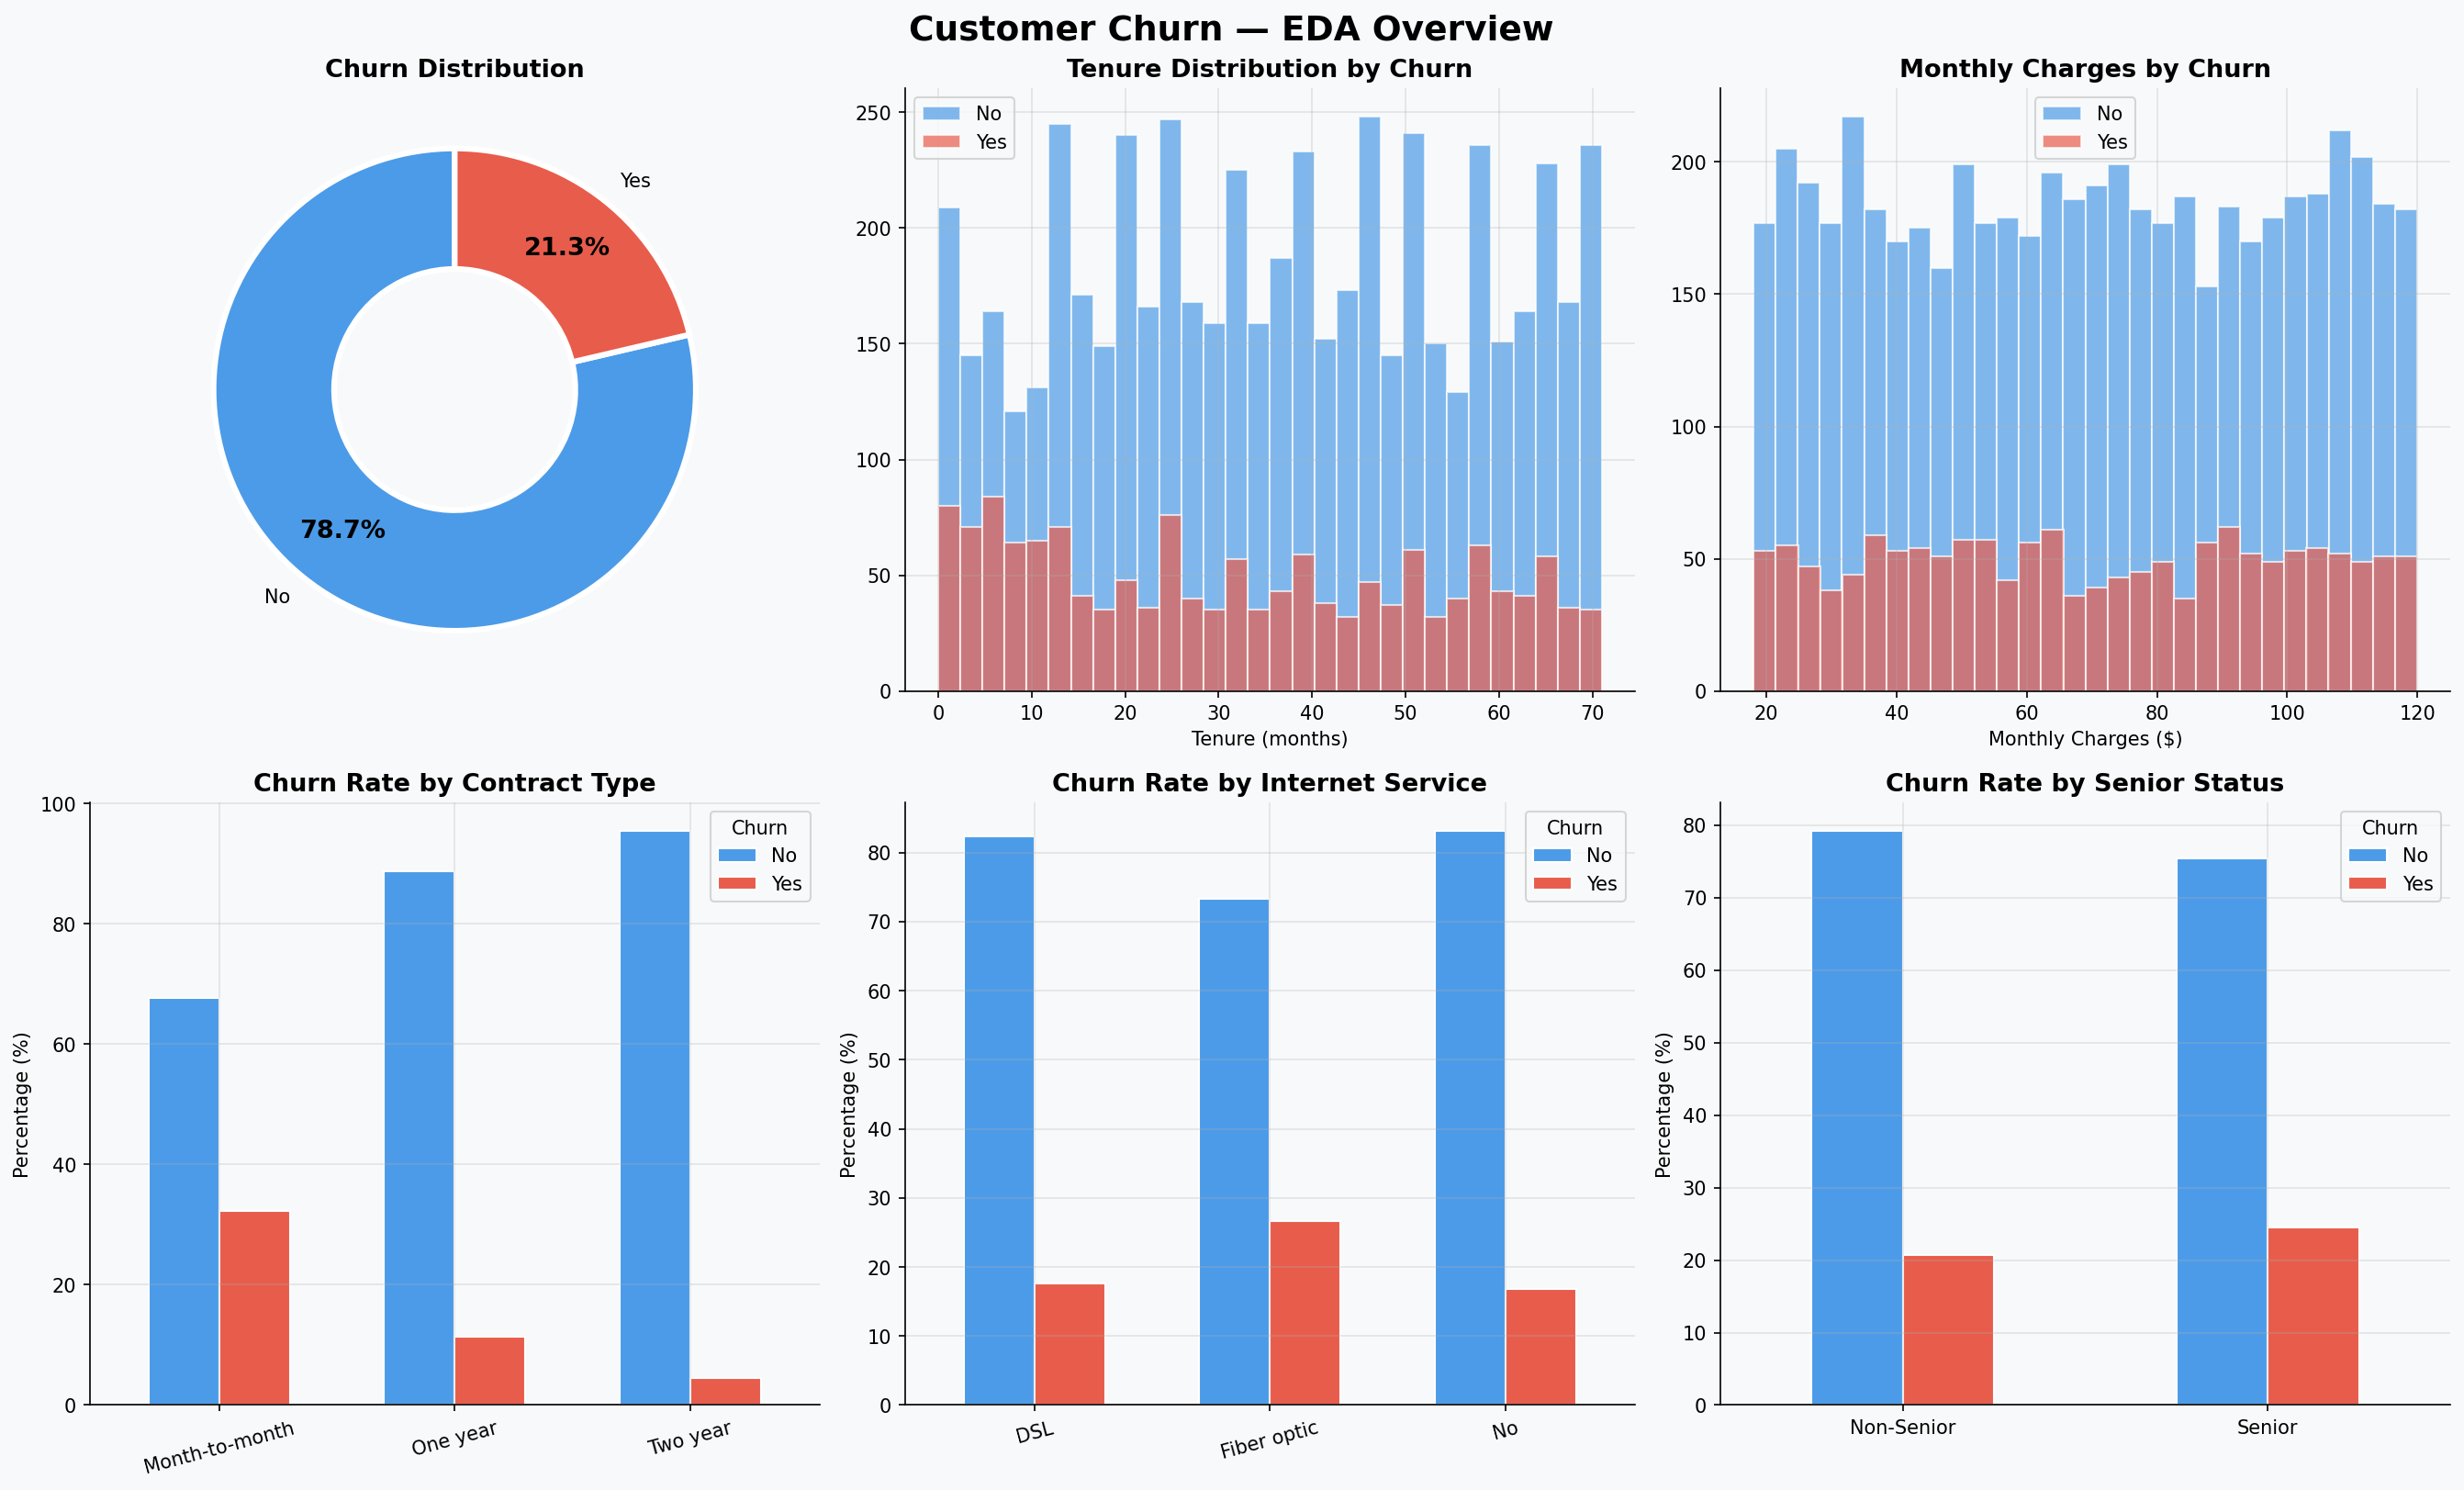


📊 02_correlation_heatmap.png


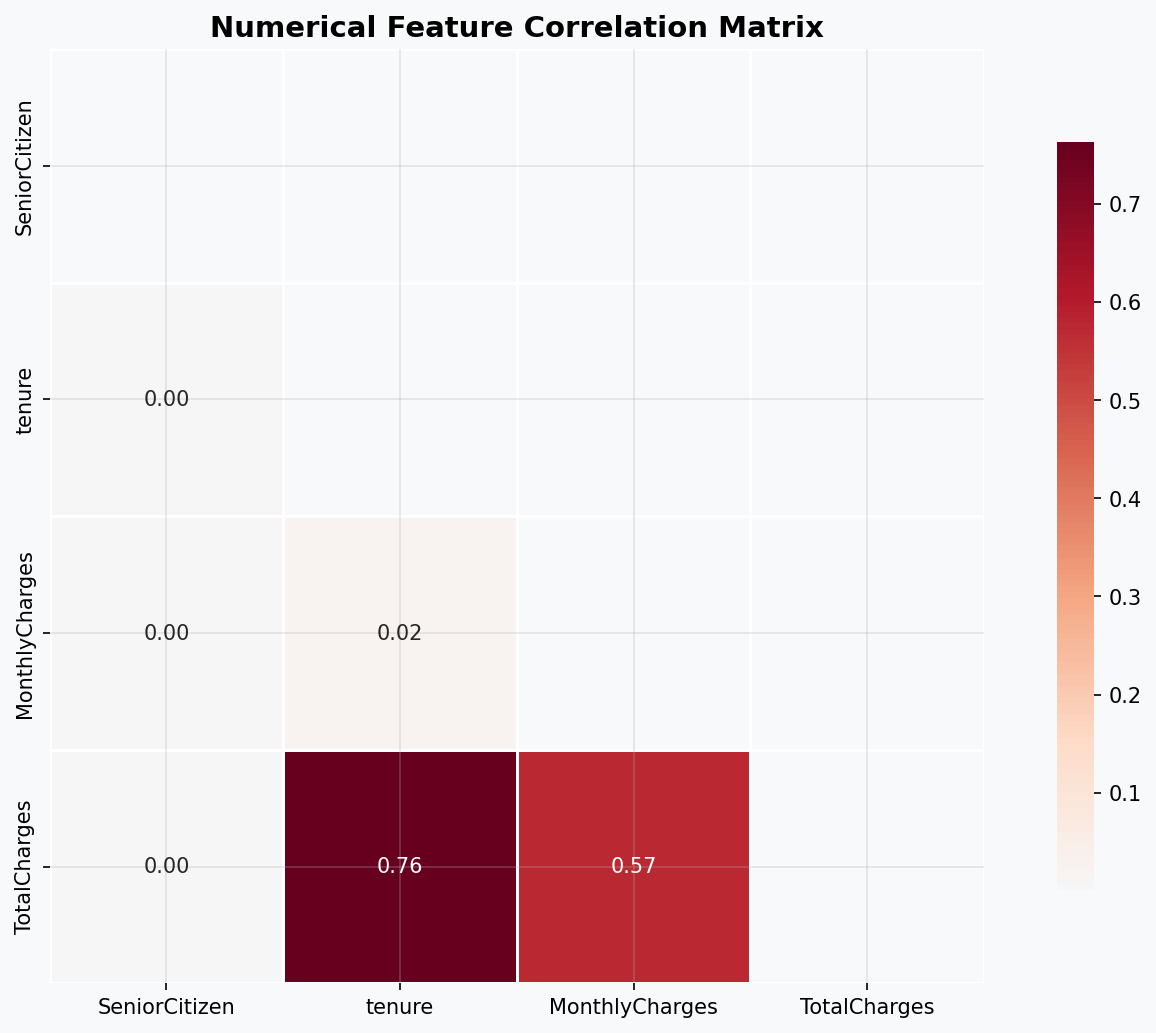


📊 03_model_comparison.png


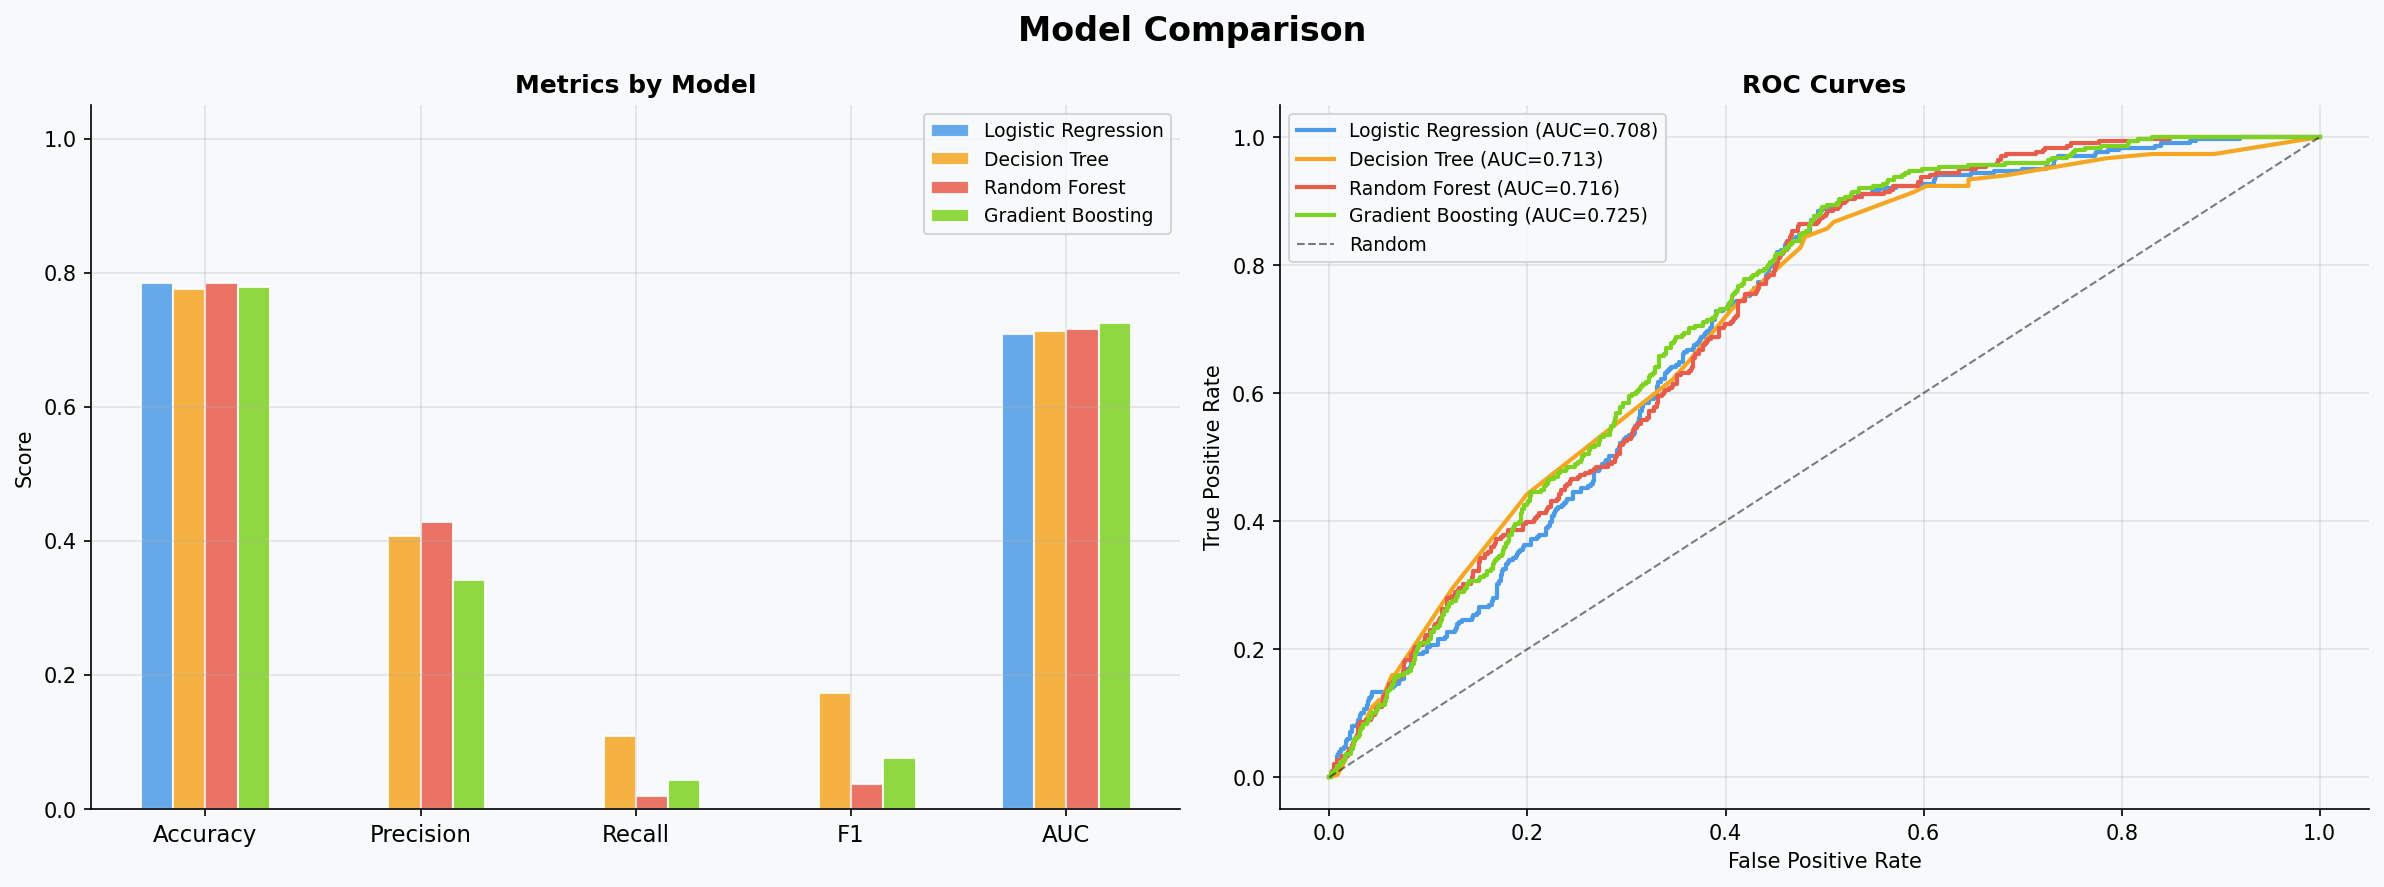


📊 04_rf_detailed.png


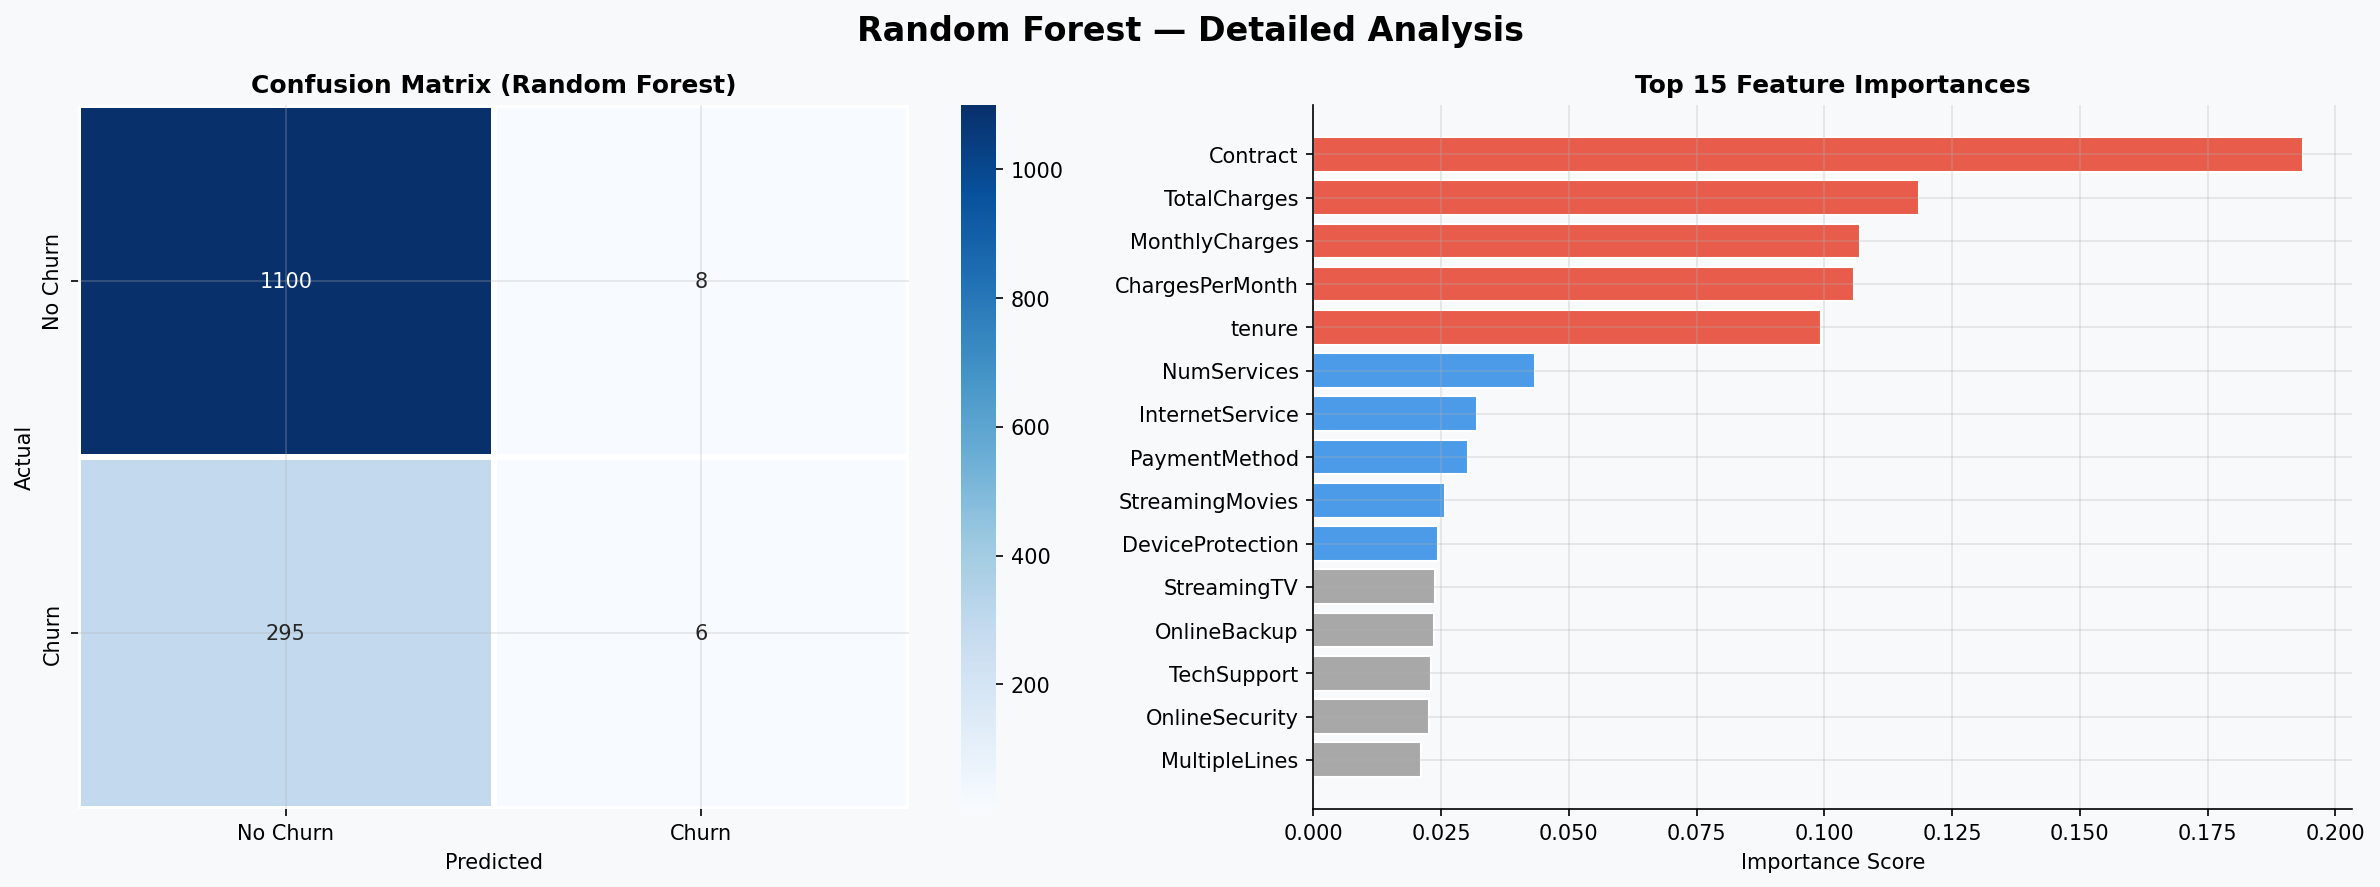

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
import os

# Show all figures
figures = os.listdir('/content/figures')
for fig in sorted(figures):
    print(f"\n📊 {fig}")
    display(Image(f'/content/figures/{fig}'))